<a href="https://colab.research.google.com/github/rodrigorissettoterra/ai-model-studies/blob/main/003_house_prices_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Comparação de modelos de regressão no California Housing Dataset

**Área:** Machine Learning  
**Tipo de problema:** Regressão

### Pergunta de estudo

> Quanto modelos não lineares melhoram a previsão do valor de imóveis em relação a baselines simples e à Regressão Linear?

### Modelos

1. Dummy Regressor — baseline ingênuo;
2. Regressão Linear;
3. Random Forest Regressor;
4. HistGradientBoosting Regressor.

### Métricas

- MAE;
- RMSE;
- R².

O conjunto de teste permanece isolado até a avaliação final.


## 1. Configuração do ambiente


In [13]:
# Importações.
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

pd.set_option("display.max_columns", None)


## 2. Carregamento do dataset

O California Housing Dataset contém informações de distritos da Califórnia derivadas do censo de 1990.

O alvo representa o **valor mediano das casas em unidades de US$ 100.000**.


In [14]:
housing = fetch_california_housing(as_frame=True)

X = housing.data.copy()
y = housing.target.copy()

print(f"Amostras: {len(X):,}")
print(f"Atributos: {X.shape[1]}")
display(X.head())


Amostras: 20,640
Atributos: 8


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [15]:
# Inspeção inicial.
summary = pd.DataFrame({
    "dtype": X.dtypes.astype(str),
    "missing": X.isna().sum(),
    "unique": X.nunique(),
})
display(summary)
display(X.describe().T)

print(y.describe())


,dtype,missing,unique
MedInc,float64,0,12928
HouseAge,float64,0,52
AveRooms,float64,0,19392
AveBedrms,float64,0,14233
Population,float64,0,3888
AveOccup,float64,0,18841
Latitude,float64,0,862
Longitude,float64,0,844


,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000


count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
Name: MedHouseVal, dtype: float64


## 3. Análise exploratória

A análise inicial observa a distribuição do alvo e as correlações lineares entre os atributos e o valor mediano.


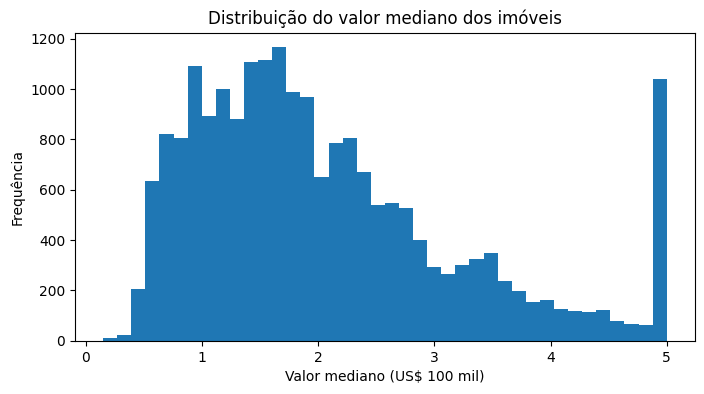

,Correlação com o alvo
MedInc,0.688075
AveRooms,0.151948
Latitude,-0.144160
HouseAge,0.105623
AveBedrms,-0.046701
Longitude,-0.045967
Population,-0.024650
AveOccup,-0.023737


In [16]:
plt.figure(figsize=(8, 4))
plt.hist(y, bins=40)
plt.title("Distribuição do valor mediano dos imóveis")
plt.xlabel("Valor mediano (US$ 100 mil)")
plt.ylabel("Frequência")
plt.show()

eda_df = X.copy()
eda_df["MedHouseVal"] = y

correlations = (
    eda_df.corr(numeric_only=True)["MedHouseVal"]
    .drop("MedHouseVal")
    .sort_values(key=np.abs, ascending=False)
)

display(correlations.to_frame("Correlação com o alvo"))


## 4. Separação entre treino, validação e teste

- 70% treino;
- 15% validação;
- 15% teste.

A validação permite comparar os modelos sem consultar o conjunto de teste.


In [17]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED
)

display(pd.DataFrame({
    "Conjunto": ["Treino", "Validação", "Teste"],
    "Amostras": [len(X_train), len(X_val), len(X_test)],
}))


,Conjunto,Amostras
0,Treino,14448
1,Validação,3096
2,Teste,3096


## 5. Modelos

### 5.1 Dummy Regressor

Prevê sempre o valor médio do conjunto de treino.  
Ele fornece uma referência mínima: um modelo útil deve superar esse baseline.

### 5.2 Regressão Linear

Estabelece uma relação linear entre os atributos e o alvo.

### 5.3 Random Forest

Captura relações não lineares por meio de um conjunto de árvores.

### 5.4 HistGradientBoosting

Constrói árvores sequencialmente, tentando corrigir os erros dos modelos anteriores.


In [6]:
models = {
    "Dummy Mean": DummyRegressor(strategy="mean"),

    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ]),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=2,
        random_state=SEED,
        n_jobs=-1,
    ),

    "HistGradientBoosting": HistGradientBoostingRegressor(
        learning_rate=0.08,
        max_iter=300,
        random_state=SEED,
    ),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"Treinado: {name}")


Treinado: Dummy Mean
Treinado: Linear Regression
Treinado: Random Forest
Treinado: HistGradientBoosting


## 6. Seleção do modelo na validação

As métricas são calculadas no conjunto de validação antes de qualquer uso do teste.


In [7]:
def regression_metrics(y_true, predictions):
    return {
        "MAE": mean_absolute_error(y_true, predictions),
        "RMSE": mean_squared_error(y_true, predictions) ** 0.5,
        "R2": r2_score(y_true, predictions),
    }

validation_results = []

for name, model in models.items():
    predictions = model.predict(X_val)
    validation_results.append({
        "Modelo": name,
        **regression_metrics(y_val, predictions),
    })

validation_results = (
    pd.DataFrame(validation_results)
    .set_index("Modelo")
    .sort_values("RMSE")
)

display(validation_results.round(4))

best_model_name = validation_results.index[0]
best_model = models[best_model_name]

print(f"Modelo selecionado pela validação: {best_model_name}")


,MAE,RMSE,R2
Modelo,,,
HistGradientBoosting,0.3058,0.4671,0.8325
Random Forest,0.3357,0.5161,0.7955
Linear Regression,0.5335,0.7354,0.5848
Dummy Mean,0.9006,1.1414,-0.0000


Modelo selecionado pela validação: HistGradientBoosting


## 7. Avaliação final no conjunto de teste

Agora os quatro modelos são avaliados no teste apenas para fins de comparação final.


In [8]:
test_results = []
test_predictions = {}

for name, model in models.items():
    predictions = model.predict(X_test)
    test_predictions[name] = predictions

    test_results.append({
        "Modelo": name,
        **regression_metrics(y_test, predictions),
    })

test_results = (
    pd.DataFrame(test_results)
    .set_index("Modelo")
    .sort_values("RMSE")
)

display(test_results.round(4))


,MAE,RMSE,R2
Modelo,,,
HistGradientBoosting,0.2942,0.4354,0.8566
Random Forest,0.3222,0.4885,0.8195
Linear Regression,0.5210,0.7213,0.6066
Dummy Mean,0.9118,1.1499,-0.0000


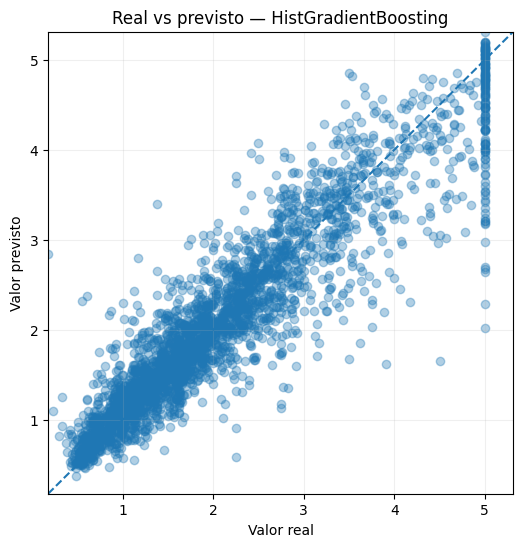

In [9]:
# Visualiza valores reais versus previstos para o melhor modelo.
best_predictions = test_predictions[best_model_name]

plt.figure(figsize=(6, 6))
plt.scatter(y_test, best_predictions, alpha=0.35)
limits = [
    min(y_test.min(), best_predictions.min()),
    max(y_test.max(), best_predictions.max()),
]
plt.plot(limits, limits, linestyle="--")
plt.xlim(limits)
plt.ylim(limits)
plt.xlabel("Valor real")
plt.ylabel("Valor previsto")
plt.title(f"Real vs previsto — {best_model_name}")
plt.grid(alpha=0.2)
plt.show()


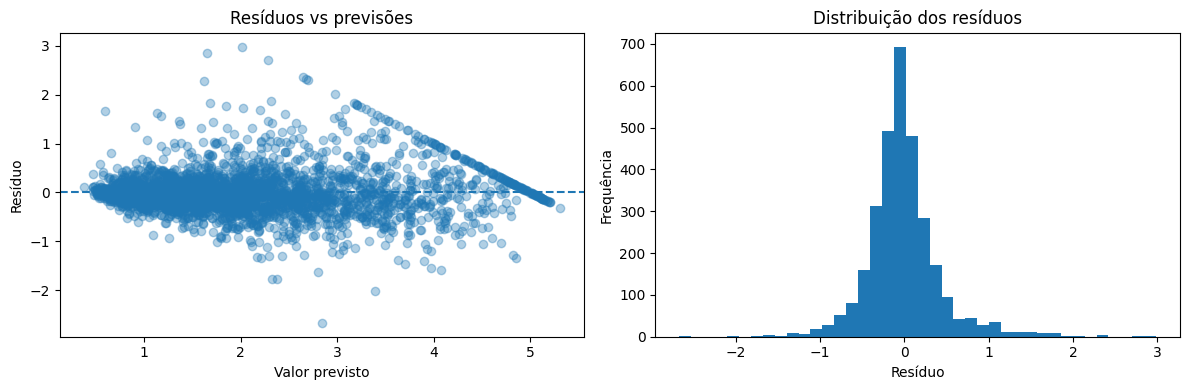

In [10]:
# Analisa resíduos.
residuals = y_test.to_numpy() - best_predictions

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(best_predictions, residuals, alpha=0.35)
axes[0].axhline(0, linestyle="--")
axes[0].set_xlabel("Valor previsto")
axes[0].set_ylabel("Resíduo")
axes[0].set_title("Resíduos vs previsões")

axes[1].hist(residuals, bins=40)
axes[1].set_xlabel("Resíduo")
axes[1].set_ylabel("Frequência")
axes[1].set_title("Distribuição dos resíduos")

plt.tight_layout()
plt.show()


## 8. Importância dos atributos

Para a Random Forest, a importância dos atributos pode ser inspecionada diretamente.

Ela indica contribuição preditiva dentro do modelo e **não causalidade**.


,Importância
MedInc,0.535402
AveOccup,0.138613
Latitude,0.086423
Longitude,0.086247
HouseAge,0.053693
AveRooms,0.043738
Population,0.029036
AveBedrms,0.026849


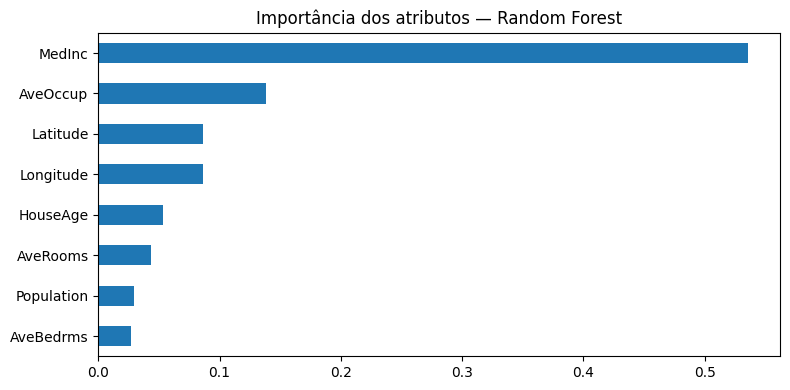

In [11]:
rf_model = models["Random Forest"]

feature_importance = (
    pd.Series(rf_model.feature_importances_, index=X.columns)
    .sort_values(ascending=False)
)

display(feature_importance.to_frame("Importância"))

plt.figure(figsize=(8, 4))
feature_importance.sort_values().plot(kind="barh")
plt.title("Importância dos atributos — Random Forest")
plt.tight_layout()
plt.show()


## 9. Conclusão

A conclusão é gerada com base nos resultados obtidos nesta execução.


In [12]:
from IPython.display import Markdown, display

winner = test_results.index[0]
winner_rmse = test_results.loc[winner, "RMSE"]
winner_mae = test_results.loc[winner, "MAE"]
winner_r2 = test_results.loc[winner, "R2"]

linear_rmse = test_results.loc["Linear Regression", "RMSE"]
improvement = (linear_rmse - winner_rmse) / linear_rmse * 100

conclusion = f'''
### Síntese dos resultados

No conjunto de teste, o modelo com menor RMSE foi **{winner}**.

- **MAE:** {winner_mae:.3f}
- **RMSE:** {winner_rmse:.3f}
- **R²:** {winner_r2:.3f}

Em relação à Regressão Linear, a redução de RMSE do melhor modelo foi de aproximadamente **{improvement:.1f}%**.

O experimento permite observar quando relações não lineares oferecem vantagem sobre uma aproximação linear.

### Limitações

- Os dados são históricos e representam distritos da Califórnia;
- o alvo é agregado por região, não por imóvel individual;
- não há variáveis modernas como juros, qualidade da construção ou condições atuais do mercado;
- métricas globais podem ocultar diferenças de desempenho entre regiões.

### Próximos experimentos

1. validação cruzada;
2. tuning de hiperparâmetros;
3. engenharia de atributos geográficos;
4. comparação com XGBoost/LightGBM;
5. análise de erro por faixa de preço e região.
'''

display(Markdown(conclusion))



### Síntese dos resultados

No conjunto de teste, o modelo com menor RMSE foi **HistGradientBoosting**.

- **MAE:** 0.294
- **RMSE:** 0.435
- **R²:** 0.857

Em relação à Regressão Linear, a redução de RMSE do melhor modelo foi de aproximadamente **39.6%**.

O experimento permite observar quando relações não lineares oferecem vantagem sobre uma aproximação linear.

### Limitações

- Os dados são históricos e representam distritos da Califórnia;
- o alvo é agregado por região, não por imóvel individual;
- não há variáveis modernas como juros, qualidade da construção ou condições atuais do mercado;
- métricas globais podem ocultar diferenças de desempenho entre regiões.

### Próximos experimentos

1. validação cruzada;
2. tuning de hiperparâmetros;
3. engenharia de atributos geográficos;
4. comparação com XGBoost/LightGBM;
5. análise de erro por faixa de preço e região.


## Referência

California Housing Dataset — `sklearn.datasets.fetch_california_housing`
